In [3]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
import healvis
from scipy.signal import windows
import astropy.io.fits as fits

In [4]:
import healpy as hp

hp.nside2resol(64, arcmin = True)  

54.967782589078496

In [16]:
b=150
c=3e8
f=65e6
lamda=c/f
res=lamda/b

In [17]:
np.rad2deg(res)*60

105.77682371645966

In [ ]:



uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.uvh5", read_data=False)  ##add frequency slice

In [3]:
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

In [4]:
with open('HERA_test_layout.csv', 'w') as f:
    f.write("Name\t Number\t BeamID\t E\t N\t U\n\n")
    for i, ant in enumerate(ants):
        f.write("HH{:d}\t {:d}\t 0\t {:8.4f}\t {:8.4f}\t {:8.4f}\n".format(ant, ant, *antpos[i]))

In [5]:
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)
uniq_bls = [red[0] for red in reds]

In [8]:
times =np.unique(uvd1.time_array) #nload
# times=np.load(path_data+"time_array_JD.npy")
freqs = uvd1.freq_array[np.where(uvd1.freq_array>50e6)]

In [8]:

uvd = healvis.simulator.setup_uvdata(array_layout="HERA_test_layout.csv",
                                telescope_location=(-30.72152777777791, 21.428305555555557, 1073.0000000093132),
                                telescope_name='HERA', freq_array=freqs, time_array=times, no_autos=False,
                                pols=['xx'], make_full=True, bls=uniq_bls)

Nbls: 6677


In [9]:
uvd.write_uvh5(path_data+"diffuse_model_test_"+uvh5name[file_number], clobber=True)
uvd.write_uvh5(path_data+"gleam_model_test_"+uvh5name[file_number], clobber=True)

## Diffuse model

In [10]:
import pygdsm
import healpy
# get GSM2016 model
GSM = pygdsm.GlobalSkyModel16()
theta, phi = healpy.pix2ang(256, np.arange(healpy.nside2npix(256)))

gsm = np.array([healpy.get_interp_val(GSM.generate(f), theta, phi) for f in freqs/1e6])

In [11]:
rot = healpy.Rotator(coord=["G", "C"])
gsm = np.array([rot.rotate_map_pixel(g) for g in gsm])
healpy.mollview(np.log10(gsm[0]))

KeyboardInterrupt: 

In [11]:
gsm_sky = healvis.sky_model.SkyModel()
gsm_sky.set_data(gsm.T[None, :, :])
gsm_sky.Nfreqs = len(freqs)
gsm_sky.Nside = 256
gsm_sky.Nskies = 1
gsm_sky.Npix = gsm.shape[-1]
gsm_sky.freqs = freqs

gsm_sky.write_hdf5(path_data+'gsm2016_nside256.hdf5', clobber=True)

...writing /net/sinatra/vault-ike/ntsikelelo/Data_H6C/gsm2016_nside256.hdf5


## GLEAM Models and Compact sources

In [93]:
hdu = fits.open('GLEAM_EGC_v2.fits')
data = hdu[1].data

RA = data['RAJ2000']
RA[RA > 240] -= 360
DE = data['DEJ2000']
alpha = data['alpha']
Fint = data['int_flux_084']
Fp = data['peak_flux_084']
cut = ((Fp) > 5) & (RA < 120) & (RA > -90)

data = data[cut]
RA = RA[cut]
DE = DE[cut]
alpha = alpha[cut]
Fint = Fint[cut]
Fp = Fp[cut]


# fix nan spix
for i in range(len(RA)):
    if np.isfinite(alpha[i]): continue
    fstr = "Fp{:03d}"
    frq = np.array([122., 130., 143., 151., 158., 166., 174., 181., 189., 197., 204.])
    x = []
    xstr = []
    for f in frq:
        xst = fstr.format(int(f))
        if xst in data.dtype.fields:
            x.append(f)
            xstr.append(xst)
    x = np.asarray(x, dtype=np.float)
    y = np.log10([data[i][xs] for xs in xstr])
    if sum(~np.isnan(y)) < 2:
        # skip this source b/c all but 1 bins are negative or nan...
        continue
    spix = np.polyfit(np.log10(x)[~np.isnan(y)], y[~np.isnan(y)], deg=1)[0]

    # if this is unreasonable, set to 0
    if spix < -3 or spix > 1:
        spix = 0
    alpha[i] = spix

invalid value encountered in greater


In [94]:
RA.shape

(1712,)

In [95]:
# load gleam files
select = (Fp > 0.1) & ~np.isnan(alpha)
RA, DE, Fp, alpha = RA[select], DE[select], Fp[select], alpha[select]
alpha[(alpha < -3) & (alpha > 1)] = 0

In [96]:
# make dummy sky model object
nside = 4
gleam = healvis.sky_model.construct_skymodel('flat_spec', freqs=freqs, Nside=nside, sigma=1)
gleam.data[:] = 0

In [97]:
# get indices for map
inds = healpy.ang2pix(nside, RA, DE, lonlat=True)

In [98]:
# insert sources
for i, ind in enumerate(inds):
    gleam.data[0, ind] = Fp[i] * (freqs / 184e6)**alpha[i]

In [99]:
# load A Team
anames, ara, adec, aF, afreq, aspix, _ = np.loadtxt('bright_sources.txt', dtype=str, skiprows=3).T
ara, adec, aF = ara.astype(float), adec.astype(float), aF.astype(float)
afreq, aspix = afreq.astype(float), aspix.astype(float)

In [100]:
# get indices for map
inds = healpy.ang2pix(nside, ara, adec, lonlat=True)

In [101]:
# insert sources
for i, ind in enumerate(inds):
    gleam.data[0, ind, :] = aF[i] * (freqs / 1e6 / afreq[i])**aspix[i]

In [102]:
gleam.data.shape

(1, 192, 1510)

In [103]:
gleam.data *= healvis.utils.jy2Tsr(freqs, bm=healpy.nside2pixarea(nside))[None, None, :]

In [104]:
gleam.write_hdf5(path_data+'gleam_nside256.hdf5', clobber=True)

...writing /net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_nside256.hdf5


## Primary Beam 

In [69]:
uvb1 = UVBeam()
uvb1.read_beamfits(path_data+"HERA-Beams/NicolasFagnoniBeams/NF_HERA_Dipole_efield_beam.fits")

In [70]:
data_freqs=freqs
uvb1.freq_interp_kind = 'cubic'
uvb1.interpolation_function = 'az_za_simple'
uvb1 = uvb1.interp(freq_array=data_freqs, new_object=True)

ValueError: Invalid number of FFT data points (0) specified.

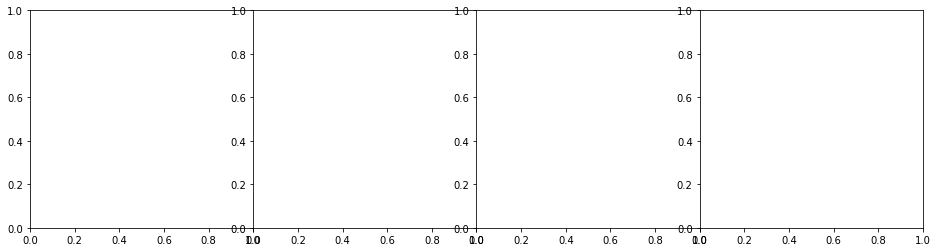

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.subplots_adjust(wspace=0)

colors = ['steelblue', 'darkorange', 'forestgreen', 'indianred']
for i, (th_min, th_max) in enumerate(zip([0, 5, 45, 70], [5, 45, 70, 90])):
    cut = (uvb1.axis2_array > th_min * np.pi / 180) & (uvb1.axis2_array < th_max * np.pi / 180)

    band1 = slice(np.argmin(np.abs(uvb1.freq_array-150e6)), np.argmin(np.abs(uvb1.freq_array-175e6)))
    freq1 = uvb1.freq_array[0, band1]
    dfft1 = np.fft.fftshift(np.fft.fft(windows.blackmanharris(len(freq1))[:, None] * uvb1.data_array[0,0,0,band1,cut],
                                       axis=1), axes=1)
    dfft1 = np.mean(np.abs(dfft1), axis=(0, 2))
    dfft1 /= np.abs(dfft1).max()
    dlys1 = np.fft.fftshift(np.fft.fftfreq(len(freq1), freq1[1]-freq1[0])) * 1e9

    ax = axes[i]
    ax.plot(dlys1, np.abs(dfft1), c=colors[i], lw=1, ls='-', label='beam')
    ax.grid()
    ax.set_yscale('log')
    ax.set_xlim(-1200, 1200)
    ax.set_ylim(1e-7, 2)
    ax.set_title(r"{} < $\theta$ < {}".format(th_min, th_max), fontsize=14)

In [105]:
# get data files
uvd_file_gleam = path_data+"gleam_model_"+uvh5name[file_number]
uvd_file_diffuse = path_data+"diffuse_model_"+uvh5name[file_number]
# get sky files
sky_file_diffuse = path_data+'gsm2016_nside256.hdf5'
sky_file_gleam = path_data+'gleam_nside256.hdf5'

# get beam files
# bfile1 = 'NF_HERA_Dipole_CCBeam_Port21_PowerBeam.fits'
uvb_file = path_data+"HERA-Beams/NicolasFagnoniBeams/NF_HERA_Dipole_efield_beam.fits"

uvd = UVData()
uvd.read(uvd_file_gleam, read_data=False)
interp_freqs = uvd.freq_array[0,:]
fchans = np.arange(interp_freqs.shape[0])

# load beam and interpolate to data frequncies
beam = healvis.beam_model.PowerBeam(uvb_file)
beam.interpolation_function = 'az_za_simple'
beam.interp_freq(interp_freqs, inplace=True, kind='cubic')

# healvis.simulator.run_simulation_partial_freq(fchans, uvd_file_diffuse, sky_file_diffuse, beam=beam,
#                                                        fov=180, smooth_beam=False)

healvis.simulator.run_simulation_partial_freq(fchans, uvd_file_gleam, sky_file_gleam, beam=beam,
                                                       fov=180, smooth_beam=False)


Doing frequency interpolation: cubic
...reading /net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_nside256.hdf5
Doing frequency interpolation: linear
Finished: 1, Elapsed 0.19min, Remain 0.003hour, MaxRSS 3.470856GB
Finished: 2, Elapsed 0.35min, Remain 0.000hour, MaxRSS 4.97714GB
...writing to /net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_zen.2459861.50015.sum.uvh5


In [106]:
hd_model=hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_zen.2459861.50015.sum.uvh5")

In [107]:
np.unique(hd_model.freq_array).shape




(123,)

In [76]:
uvb1.interp?

Signature:
uvb1.interp(
    az_array=None,
    za_array=None,
    az_za_grid=False,
    healpix_nside=None,
    healpix_inds=None,
    freq_array=None,
    freq_interp_tol=1.0,
    polarizations=None,
    return_bandpass=False,
    reuse_spline=False,
    spline_opts=None,
    new_object=False,
    run_check=True,
    check_extra=True,
    run_check_acceptability=True,
)
Docstring:
Interpolate beam to given frequency, az & za locations or Healpix pixel centers.

Parameters
----------
az_array : array_like of floats, optional
    Azimuth values to interpolate to in radians, either specifying the
    azimuth positions for every interpolation point or specifying the
    azimuth vector for a meshgrid if az_za_grid is True.
za_array : array_like of floats, optional
    Zenith values to interpolate to in radians, either specifying the
    zenith positions for every interpolation point or specifying the
    zenith vector for a meshgrid if az_za_grid is True.
az_za_grid : bool
    Option to tr